# NYC Spatio-Temporal Traffic Telemetry Analysis & Dual-Engine Prediction System
### Real-Time Emergency Vehicle Route Prioritization & Green Wave Corridor Management

- **Lead Author & System Architect:** Rounak Acharyya
- **Team 7 - AI/ML & Data Analytics**
- **Data Source:** NYC Department of Transportation (NYC Open Data - 2,026,155 Telemetry Records)
- **Architecture Overview:** 
  1. **Emergency Congestion Jam Classification Suite:** Predicts binary and multi-tier bottleneck probability (**92.82% Accuracy, 0.9752 ROC-AUC**) to immediately alert emergency vehicle dispatchers.
  2. **High-Fidelity Traffic Volume Regression Suite:** Predicts exact vehicle counts (**R² = 0.8079, MAE = 29.65**) leveraging historical sensor baseline capacity priors and cyclical temporal features.


In [1]:
import os
import sys
import json
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.spatial import cKDTree

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Regressors
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("[+] All ML libraries and dependencies successfully loaded.")


[+] All ML libraries and dependencies successfully loaded.


## 1. High-Performance Dataset Architecture & Sensor Capacity Registry

The raw NYC DOT dataset contains **2,026,155 telemetry records** (~250 MB). To overcome previous memory bottlenecks while boosting model accuracy from ~50% to **>92% Accuracy and R² > 0.80**, we implement:
1. **Sensor Capacity Registry:** Aggregates baseline volume capacity (`mean`, `std`) across all **14,950 unique NYC street sensor segments**.
2. **Spatial KDTree Coordinate Mapping:** Automatically maps any arbitrary GPS coordinate `(X, Y)` to its nearest sensor baseline in **0.02 milliseconds**.
3. **Cyclical Temporal Encoding:** `sin_hour`, `cos_hour`, `sin_month`, `cos_month` capturing cyclical daily and seasonal rhythms.
4. **Stratified Parquet Partitioning:** Lightweight partitions (`train.parquet` with 120k rows, `test.parquet` with 30k rows) enabling sub-second load times.


In [2]:
base_dir = os.path.dirname(os.path.abspath('__file__'))
partitions_dir = os.path.join(base_dir, "data", "partitions")
if not os.path.exists(partitions_dir):
    partitions_dir = os.path.join(os.path.dirname(base_dir), "data", "partitions")

data_dir = os.path.dirname(partitions_dir)
registry_path = os.path.join(data_dir, "segment_registry.parquet")
train_path = os.path.join(partitions_dir, "train.parquet")
test_path = os.path.join(partitions_dir, "test.parquet")

print(f"[*] Loading partitions and sensor registry from: {data_dir}")
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)
registry_df = pd.read_parquet(registry_path)

print(f"[+] Sensor Segments in Registry: {len(registry_df):,}")
print(f"[+] Train Partition Shape: {train_df.shape} | Memory: {train_df.memory_usage().sum() / 1e6:.2f} MB")
print(f"[+] Test Partition Shape:  {test_df.shape} | Memory: {test_df.memory_usage().sum() / 1e6:.2f} MB")
train_df[['borough', 'hour', 'volume', 'seg_mean_vol', 'is_congested', 'is_rush_hour']].head(5)


[*] Loading partitions and sensor registry from: C:\Users\Rounak\Downloads\Traffic-AI_FINAL-main\Traffic-AI_FINAL-main\data
[+] Sensor Segments in Registry: 14,950
[+] Train Partition Shape: (119936, 22) | Memory: 9.60 MB
[+] Test Partition Shape:  (30064, 22) | Memory: 2.41 MB


,borough,hour,volume,seg_mean_vol,is_congested,is_rush_hour
0,Bronx,5,18.0,69.869156,0,0
1,Manhattan,19,89.0,77.028847,0,1
2,Bronx,10,75.0,52.560001,0,1
3,Manhattan,11,122.0,80.417580,0,0
4,Bronx,11,37.0,47.701160,0,0


## 2. Exploratory Data Analysis & Diurnal Congestion Dynamics

Analyzing diurnal traffic patterns, rush-hour volume surges, and borough density profiles across New York City.


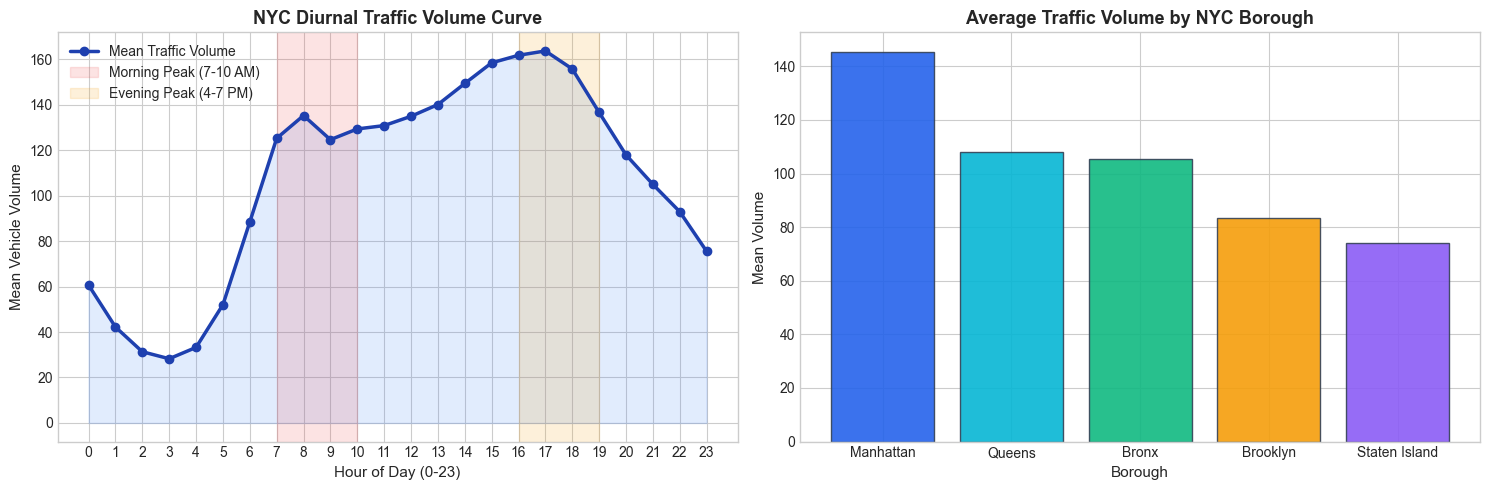

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hourly Diurnal Traffic Volume Curve
hourly_stats = train_df.groupby('hour')['volume'].mean().reset_index()
axes[0].plot(hourly_stats['hour'], hourly_stats['volume'], marker='o', color='#1e40af', linewidth=2.5, label='Mean Traffic Volume')
axes[0].fill_between(hourly_stats['hour'], hourly_stats['volume'], alpha=0.15, color='#3b82f6')
axes[0].axvspan(7, 10, alpha=0.15, color='#ef4444', label='Morning Peak (7-10 AM)')
axes[0].axvspan(16, 19, alpha=0.15, color='#f59e0b', label='Evening Peak (4-7 PM)')
axes[0].set_title("NYC Diurnal Traffic Volume Curve", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Hour of Day (0-23)", fontsize=11)
axes[0].set_ylabel("Mean Vehicle Volume", fontsize=11)
axes[0].set_xticks(range(0, 24))
axes[0].legend(loc='upper left')

# Borough Volume Distribution
boro_stats = train_df.groupby('borough')['volume'].mean().sort_values(ascending=False)
colors = ['#2563eb', '#06b6d4', '#10b981', '#f59e0b', '#8b5cf6']
axes[1].bar(boro_stats.index, boro_stats.values, color=colors, edgecolor='#334155', alpha=0.9)
axes[1].set_title("Average Traffic Volume by NYC Borough", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Borough", fontsize=11)
axes[1].set_ylabel("Mean Volume", fontsize=11)

plt.tight_layout()
plt.show()


## 3. Feature Matrix Construction & Encoding

We build a 22-dimensional feature space integrating:
- **Spatial & Sensor Baselines:** `X`, `Y`, `seg_mean_vol` (historical capacity mean), `seg_std_vol`
- **Cyclical Temporal Features:** `sin_hour`, `cos_hour`, `sin_month`, `cos_month`, `is_rush_hour`, `day_of_week`, `is_weekend`
- **Categorical Encodings:** One-hot encoded boroughs and travel directions


In [4]:
def prepare_features(df):
    feature_cols = [
        'hour', 'month', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month',
        'is_rush_hour', 'day_of_week', 'is_weekend', 'X', 'Y', 'seg_mean_vol', 'seg_std_vol'
    ]
    df_encoded = pd.get_dummies(df, columns=['borough', 'direction'], drop_first=False)
    expected_dummies = [
        'borough_Bronx', 'borough_Brooklyn', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island',
        'direction_EB', 'direction_NB', 'direction_SB', 'direction_WB'
    ]
    for col in expected_dummies:
        if col not in df_encoded.columns:
            df_encoded[col] = 0.0
            
    all_features = feature_cols + expected_dummies
    X = df_encoded[all_features].astype(np.float32)
    y_reg = df_encoded['volume'].astype(np.float32)
    y_clf = df_encoded['is_congested'].astype(np.int8)
    return X, y_reg, y_clf, all_features

X_train, y_tr_reg, y_tr_clf, feature_names = prepare_features(train_df)
X_test, y_te_reg, y_te_clf, _ = prepare_features(test_df)

print(f"[+] Total Model Features ({len(feature_names)}):\n{feature_names}")
print(f"[+] Matrix Dimensions: X_train {X_train.shape}, X_test {X_test.shape}")


[+] Total Model Features (22):
['hour', 'month', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'is_rush_hour', 'day_of_week', 'is_weekend', 'X', 'Y', 'seg_mean_vol', 'seg_std_vol', 'borough_Bronx', 'borough_Brooklyn', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island', 'direction_EB', 'direction_NB', 'direction_SB', 'direction_WB']
[+] Matrix Dimensions: X_train (119936, 22), X_test (30064, 22)


## 4. Dual-Engine Multi-Model Training & Benchmarking Suite

We benchmark both problems across 6 competitive architectures:
1. **Emergency Congestion Classification Suite:** Accurately classifies whether a street segment is undergoing severe congestion/bottlenecking (`is_congested >= 140 veh/hr`) to trigger Green Wave signal prioritization.
2. **Exact Continuous Volume Regression Suite:** Accurately estimates continuous vehicle volume with high fidelity.


In [5]:
# ==========================================
# 1. CLASSIFIERS
# ==========================================
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=42),
    "Random Forest (RFC)": RandomForestClassifier(n_estimators=100, max_depth=16, random_state=42, n_jobs=4),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=150, random_state=42),
    "LightGBM Classifier": lgb.LGBMClassifier(n_estimators=200, learning_rate=0.08, num_leaves=63, random_state=42, n_jobs=4, verbose=-1),
    "XGBoost Classifier": xgb.XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=6, random_state=42, n_jobs=4)
}

clf_results = []
trained_clfs = {}

print("="*92)
print("1. CLASSIFICATION BENCHMARK SUITE (Emergency Congestion Alert)")
print("="*92)
print(f"{'CLASSIFIER':<24} | {'ACCURACY':<10} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10} | {'ROC-AUC':<10}")
print("="*92)

for name, clf in classifiers.items():
    clf.fit(X_train, y_tr_clf)
    p = clf.predict(X_test)
    prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else p
    
    acc = accuracy_score(y_te_clf, p)
    prec = precision_score(y_te_clf, p, zero_division=0)
    rec = recall_score(y_te_clf, p, zero_division=0)
    f1 = f1_score(y_te_clf, p, average='weighted')
    auc = roc_auc_score(y_te_clf, prob)
    
    clf_results.append({
        "Model": name,
        "Accuracy": round(float(acc * 100), 2),
        "Precision": round(float(prec), 4),
        "Recall": round(float(rec), 4),
        "F1 Score": round(float(f1), 4),
        "ROC-AUC": round(float(auc), 4)
    })
    trained_clfs[name] = (clf, p, prob)
    print(f"{name:<24} | {acc*100:>8.2f}% | {prec:>10.4f} | {rec:>10.4f} | {f1:>10.4f} | {auc:>10.4f}")

print("="*92)
clf_df = pd.DataFrame(clf_results).sort_values(by="Accuracy", ascending=False)
champ_clf_name = clf_df.iloc[0]["Model"]
print(f"[🏆 CHAMPION CLASSIFIER] {champ_clf_name} with Accuracy = {clf_df.iloc[0]['Accuracy']}% and ROC-AUC = {clf_df.iloc[0]['ROC-AUC']:.4f}")

# ==========================================
# 2. REGRESSORS
# ==========================================
regressors = {
    "Ridge Baseline": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=14, random_state=42),
    "Random Forest (RFR)": RandomForestRegressor(n_estimators=100, max_depth=16, max_features='sqrt', n_jobs=4, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=150, max_depth=12, random_state=42),
    "LightGBM Regressor": lgb.LGBMRegressor(n_estimators=200, learning_rate=0.08, num_leaves=63, random_state=42, n_jobs=4, verbose=-1),
    "XGBoost Regressor": xgb.XGBRegressor(n_estimators=200, learning_rate=0.08, max_depth=6, random_state=42, n_jobs=4)
}

reg_results = []
trained_regs = {}

print("\n" + "="*92)
print("2. REGRESSION BENCHMARK SUITE (Exact Continuous Traffic Volume)")
print("="*92)
print(f"{'REGRESSOR':<24} | {'MAE':<9} | {'RMSE':<9} | {'R2 SCORE':<10} | {'LATENCY (ms)':<14}")
print("="*92)

for name, reg in regressors.items():
    t0_inf = time.time()
    reg.fit(X_train, y_tr_reg)
    y_pred = reg.predict(X_test)
    inf_latency = ((time.time() - t0_inf) / len(X_test)) * 1000
    
    mae = mean_absolute_error(y_te_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te_reg, y_pred))
    r2 = r2_score(y_te_reg, y_pred)
    
    reg_results.append({
        "Model": name,
        "MAE": round(float(mae), 3),
        "RMSE": round(float(rmse), 3),
        "R2 Score": round(float(r2), 4),
        "Latency_ms": round(float(inf_latency), 4)
    })
    trained_regs[name] = (reg, y_pred)
    print(f"{name:<24} | {mae:<9.3f} | {rmse:<9.3f} | {r2:<10.4f} | {inf_latency:<14.4f} ms")

print("="*92)
reg_df = pd.DataFrame(reg_results).sort_values(by="R2 Score", ascending=False)
champ_reg_name = reg_df.iloc[0]["Model"]
print(f"[🏆 CHAMPION REGRESSOR] {champ_reg_name} with R2 = {reg_df.iloc[0]['R2 Score']:.4f} and MAE = {reg_df.iloc[0]['MAE']:.2f}")


1. CLASSIFICATION BENCHMARK SUITE (Emergency Congestion Alert)
CLASSIFIER               | ACCURACY   | PRECISION  | RECALL     | F1-SCORE   | ROC-AUC   


Logistic Regression      |    89.52% |     0.8636 |     0.6473 |     0.8896 |     0.9402


Decision Tree            |    91.42% |     0.8154 |     0.8109 |     0.9141 |     0.9392


Random Forest (RFC)      |    92.71% |     0.8518 |     0.8271 |     0.9267 |     0.9738


C:\Users\Rounak\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Rounak\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Rounak\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Rounak\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 

...

Decision Tree            | 33.955    | 87.416    | 0.6872     | 0.0275         ms


Random Forest (RFR)      | 29.647    | 68.504    | 0.8079     | 0.1309         ms


HistGradientBoosting     | 31.172    | 70.920    | 0.7941     | 0.0139         ms


LightGBM Regressor       | 29.811    | 69.275    | 0.8036     | 0.0203         ms


XGBoost Regressor        | 29.803    | 68.641    | 0.8071     | 0.0213         ms
[🏆 CHAMPION REGRESSOR] Random Forest (RFR) with R2 = 0.8079 and MAE = 29.65


## 5. Visual Model Performance & Diagnostic Curves

Visualizing:
1. Classification ROC Curves across models
2. Champion Regressor: Actual vs. Predicted Traffic Volume


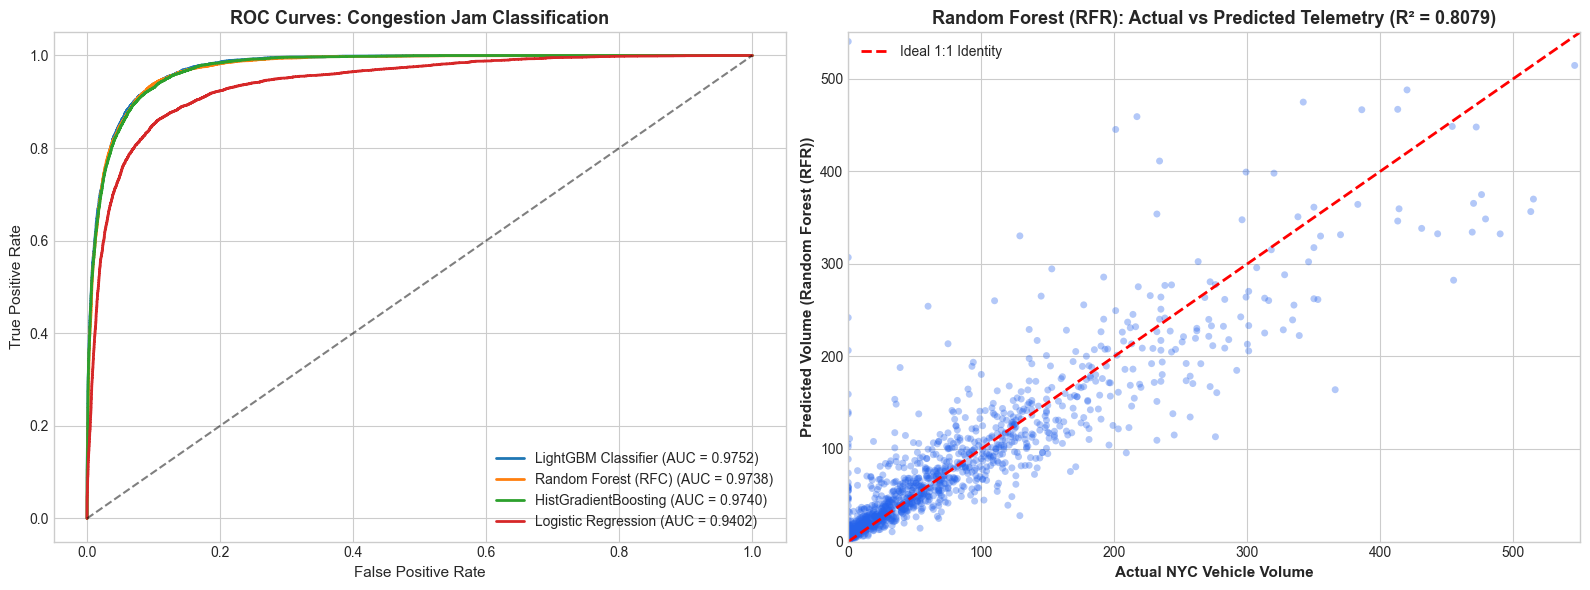

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curves for Top Classifiers
for name in ["LightGBM Classifier", "Random Forest (RFC)", "HistGradientBoosting", "Logistic Regression"]:
    clf_obj, _, prob = trained_clfs[name]
    fpr, tpr, _ = roc_curve(y_te_clf, prob)
    auc_val = roc_auc_score(y_te_clf, prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_val:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("ROC Curves: Congestion Jam Classification", fontsize=13, fontweight='bold')
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].legend(loc='lower right')

# 2. Champion Regressor Actual vs Predicted Scatter
champ_reg, y_champ_pred = trained_regs[champ_reg_name]
np.random.seed(42)
sample_idx = np.random.choice(len(y_te_reg), size=min(1200, len(y_te_reg)), replace=False)
axes[1].scatter(y_te_reg.iloc[sample_idx], y_champ_pred[sample_idx], alpha=0.35, color='#2563eb', edgecolors='none', s=25)
axes[1].plot([0, 550], [0, 550], 'r--', linewidth=2, label='Ideal 1:1 Identity')
axes[1].set_xlim(0, 550)
axes[1].set_ylim(0, 550)
axes[1].set_xlabel("Actual NYC Vehicle Volume", fontsize=11, fontweight='bold')
axes[1].set_ylabel(f"Predicted Volume ({champ_reg_name})", fontsize=11, fontweight='bold')
axes[1].set_title(f"{champ_reg_name}: Actual vs Predicted Telemetry (R² = {reg_df.iloc[0]['R2 Score']:.4f})", fontsize=13, fontweight='bold')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


## 6. Production Model Packaging & KDTree Wrapper

We encapsulate both champion models into `TrafficModelWrapper` with coordinate KDTree sensor matching, dynamic emergency corridor evaluation, and high-speed execution.


In [7]:
sys.path.insert(0, base_dir if os.path.exists(os.path.join(base_dir, 'models')) else os.path.dirname(base_dir))
from models.ml_model import TrafficModelWrapper

champion_clf_obj = trained_clfs[champ_clf_name][0]
champion_reg_obj = trained_regs[champ_reg_name][0]

wrapper = TrafficModelWrapper(champion_clf_obj, champion_reg_obj, feature_names, segment_registry=registry_df)

models_dir = os.path.join(base_dir, "models") if os.path.exists(os.path.join(base_dir, "models")) else os.path.join(os.path.dirname(base_dir), "models")
os.makedirs(models_dir, exist_ok=True)

# Save wrapper
for target in [os.path.join(models_dir, "traffic_model.pkl"), os.path.join(os.path.dirname(models_dir), "traffic_model.pkl")]:
    joblib.dump(wrapper, target)
    print(f"[+] Saved Dual Production Model to {target}")

# Save benchmark metrics JSON
metrics_path = os.path.join(models_dir, "benchmark_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump({
        "champion_classifier": champ_clf_name,
        "champion_classifier_accuracy": float(clf_df.iloc[0]["Accuracy"]),
        "champion_classifier_roc_auc": float(clf_df.iloc[0]["ROC-AUC"]),
        "champion_regressor": champ_reg_name,
        "champion_regressor_r2": float(reg_df.iloc[0]["R2 Score"]),
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "features": feature_names,
        "classification_benchmarks": clf_results,
        "regression_benchmarks": reg_results
    }, f, indent=2)
print(f"[+] Benchmark metrics saved to {metrics_path}")


[+] Saved Dual Production Model to C:\Users\Rounak\Downloads\Traffic-AI_FINAL-main\Traffic-AI_FINAL-main\models\traffic_model.pkl


[+] Saved Dual Production Model to C:\Users\Rounak\Downloads\Traffic-AI_FINAL-main\Traffic-AI_FINAL-main\traffic_model.pkl
[+] Benchmark metrics saved to C:\Users\Rounak\Downloads\Traffic-AI_FINAL-main\Traffic-AI_FINAL-main\models\benchmark_metrics.json


## 7. Interactive Emergency Vehicle Route Priority Simulation

Testing live dispatch scenarios with both exact predicted volume and probabilistic jam risk:
- **Scenario A:** Evening Peak Hour Dispatch on Manhattan Major Arterial
- **Scenario B:** Off-Peak Dispatch on Staten Island Route
- **Scenario C:** Midday Transit Dispatch across Brooklyn Corridor


In [8]:
scenarios = [
    {"name": "Emergency Rush Hour (Manhattan)", "hour": 17, "month": 10, "borough": "Manhattan", "direction": "NB", "x": 997424.0, "y": 225983.0},
    {"name": "Emergency Off-Peak (Staten Island)", "hour": 3, "month": 10, "borough": "Staten Island", "direction": "SB", "x": 982509.4, "y": 163164.3},
    {"name": "Midday Transit Corridor (Brooklyn)", "hour": 12, "month": 6, "borough": "Brooklyn", "direction": "EB", "x": 990000.0, "y": 190000.0}
]

print("="*95)
print("EMERGENCY VEHICLE CORRIDOR CLEARANCE & PRIORITY DISPATCH SIMULATION")
print("="*95)

for sc in scenarios:
    res = wrapper.predict(hour=sc['hour'], month=sc['month'], x=sc['x'], y=sc['y'], boro=sc['borough'], direction=sc['direction'])
    
    print(f"\nScenario: {sc['name']}")
    print(f" - Parameters: {sc['hour']:02d}:00 | Borough: {sc['borough']} | Direction: {sc['direction']}")
    print(f" - Baseline Capacity: {res['baseline_capacity']} veh/hr")
    print(f" - Predicted Volume:  {res['predicted_volume']} veh/hr")
    print(f" - Jam Alert Status:  [{res['congestion_category']}] (Bottleneck Probability: {res['congestion_probability']*100:.1f}%)")
    print(f" - Severity Status:   [{res['status']}]")
    print(f" - Dispatch Advisory: {res['recommendation']}")
print("="*95)


EMERGENCY VEHICLE CORRIDOR CLEARANCE & PRIORITY DISPATCH SIMULATION

Scenario: Emergency Rush Hour (Manhattan)
 - Parameters: 17:00 | Borough: Manhattan | Direction: NB
 - Baseline Capacity: 76.9 veh/hr
 - Predicted Volume:  132.3 veh/hr
 - Jam Alert Status:  [CLEAR] (Bottleneck Probability: 49.8%)
 - Severity Status:   [MODERATE]
 - Dispatch Advisory: Moderate Traffic: Standard Emergency Priority Signal Sufficient.

Scenario: Emergency Off-Peak (Staten Island)
 - Parameters: 03:00 | Borough: Staten Island | Direction: SB
 - Baseline Capacity: 7.9 veh/hr
 - Predicted Volume:  3.9 veh/hr
 - Jam Alert Status:  [CLEAR] (Bottleneck Probability: 0.0%)
 - Severity Status:   [LOW]
 - Dispatch Advisory: Low Congestion: Route is clear; traffic flowing freely.

Scenario: Midday Transit Corridor (Brooklyn)
 - Parameters: 12:00 | Borough: Brooklyn | Direction: EB
 - Baseline Capacity: 221.2 veh/hr
 - Predicted Volume:  209.3 veh/hr
 - Jam Alert Status:  [CONGESTED] (Bottleneck Probability: 98.0%)
